<a href="https://colab.research.google.com/github/DiegoSantosOP/ChalengerAluraStoreBR/blob/main/AluraStoreBr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [1]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url1)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [2]:
from urllib.request import urlopen
import csv

urls = [url1, url2, url3, url4]

#função para ler csv apartir da URL
def ler_csv(url):
  dados=[]
  with urlopen(url) as resposta:
    linhas = resposta.read().decode('utf-8').splitlines()
    leitor = csv.DictReader(linhas)
    for linha in leitor:
      dados.append(linha)
  return dados

#analise de faturamento
faturamento_total = 0

for i, url in enumerate(urls):
  dados_loja = ler_csv(url)
  faturamento_loja = 0

  for venda in dados_loja:
    preco = float(venda['Preço']) #somamos apensas os preços
    faturamento_loja += preco

  print(f'Faturamento loja {i+1}: R${faturamento_loja:.2f}')
  faturamento_total += faturamento_loja

#mostra faturamento total
print(f'\nFaturamento total de todas as lojas: R${faturamento_total:.2f}')



Faturamento loja 1: R$1534509.12
Faturamento loja 2: R$1488459.06
Faturamento loja 3: R$1464025.03
Faturamento loja 4: R$1384497.58

Faturamento total de todas as lojas: R$5871490.79


# 2. Vendas por Categoria


In [3]:
# Dicionário para armazenar as vendas por categoria
vendas_por_categoria = {}

# Laço para processar todas as lojas
for i, url in enumerate(urls):
  dados_loja = ler_csv(url)
  print(f'\nVendas por categoria na loja {i+1}: ')

  # Dicionário da loja atual
  categorias_loja = {}

  for venda in dados_loja:
    categoria = venda['Categoria do Produto']
    preco = float(venda['Preço'])
    valor_venda = preco  # Cada linha representa uma venda de 1 unidade

    # Adicionando ao dicionário da loja atual
    if categoria in categorias_loja:
      categorias_loja[categoria] += valor_venda
    else:
      categorias_loja[categoria] = valor_venda

    # Adicionando ao dicionário geral
    if categoria in vendas_por_categoria:
      vendas_por_categoria[categoria] += valor_venda
    else:
      vendas_por_categoria[categoria] = valor_venda

  # Mostra resultados para esta loja
  for categoria, valor in categorias_loja.items():
    print(f'{categoria}: R${valor:.2f}')

# Mostra resultados totais
print(f'\nVendas totais por categoria (todas as lojas): ')
for categoria, valor in vendas_por_categoria.items():
  print(f' {categoria}:  R${valor:.2f}')

# Calculando o total geral
total_geral = sum(vendas_por_categoria.values())
print(f'\nTotal geral de vendas: R${total_geral:.2f}')





Vendas por categoria na loja 1: 
eletronicos: R$572659.23
moveis: R$250178.11
brinquedos: R$23993.78
eletrodomesticos: R$484913.36
utilidades domesticas: R$16931.48
esporte e lazer: R$52387.55
livros: R$11713.92
instrumentos musicais: R$121731.69

Vendas por categoria na loja 2: 
moveis: R$235234.68
instrumentos musicais: R$139987.03
esporte e lazer: R$46326.09
eletronicos: R$547773.71
utilidades domesticas: R$19662.86
brinquedos: R$21262.21
eletrodomesticos: R$464758.13
livros: R$13454.35

Vendas por categoria na loja 3: 
eletrodomesticos: R$438984.89
moveis: R$268095.56
instrumentos musicais: R$103174.45
esporte e lazer: R$47456.10
eletronicos: R$547699.92
brinquedos: R$25869.20
utilidades domesticas: R$20080.21
livros: R$12664.70

Vendas por categoria na loja 4: 
eletrodomesticos: R$377680.65
moveis: R$256705.65
esporte e lazer: R$44465.65
livros: R$12427.77
eletronicos: R$545966.86
instrumentos musicais: R$100136.50
brinquedos: R$27015.67
utilidades domesticas: R$20098.83

Vendas 

# 3. Média de Avaliação das Lojas

In [4]:
#Calcular a avaliação media de cada loja
for i, url in enumerate(urls):
  dados_loja = ler_csv(url)

  #Variáveis para a média
  soma_avaliacoes = 0
  quantidade_produtos = 0

  for produto in dados_loja:
      try:
      #testando para os nomes de colunas possíveis]
        if 'Avaliação da compra' in produto:
          avaliacao = float(produto['Avaliação da compra'])
        elif 'Avaliação da compra' in produto:
          avaliacao = float(produto['Avaliação da compra'])
        elif 'Avaliação da compra' in produto:
          avaliacao = float(produto['Avaliação da compra'])
        else:
          #se a coluna não for encontrada serão impressas as chaves disponíveis
          print(f'Chaves disponíveis na loja {i+1}: ', produto.keys())
          raise KeyError('Não encontramos a coluna de avaliação')

        soma_avaliacoes += avaliacao
        quantidade_produtos += 1
      except (ValueError, KeyError) as e:
        if isinstance(e, KeyError):
          raise
      #Ignoramos valores que não podem ser convertidos pra float
        continue

  if quantidade_produtos > 0:
      avaliacao_media = soma_avaliacoes/quantidade_produtos
      print(f'Avaliação média da loja {i+1}: {avaliacao_media:.2f}')
  else:
    print(f'Não foi possível processar as avaliações para a loja {i+1}')



Avaliação média da loja 1: 3.98
Avaliação média da loja 2: 4.04
Avaliação média da loja 3: 4.05
Avaliação média da loja 4: 4.00


# 4. Produtos Mais e Menos Vendidos

In [5]:
from collections import defaultdict
from urllib.request import urlopen
import csv

#Função para calcular o top 3 produtos que geraram mais e menos dinheiro
def top_produtos(dados_loja, numero_loja):
    ganhos_por_produto = defaultdict(float)

    for venda in dados_loja:
      produto = venda['Produto']
      preco = float(venda['Preço'])
      #Agora usamos só o preço, sem multiplicar pela quantidade de parcelas
      ganhos_por_produto[produto] += preco

    #convertendo para lista ordenada
    produtos_ordenados = sorted(ganhos_por_produto.items(), key=lambda x: x[1], reverse= True)

    top_mais_vendidos = produtos_ordenados[:3]
    top_menos_vendidos = produtos_ordenados[-3:]

    print(f'\nLoja {numero_loja} - TOP 3 Produtos que geraram mais dinheiro: ')
    for produto, ganho in top_mais_vendidos:
        print(f'{produto} - ganhos: R${ganho:.2f}')

    print(f'\nLoja {numero_loja} - TOP 3 Produtos que geraram menos dinheiro: ')
    for produto, ganho in top_menos_vendidos:
        print(f'{produto} - ganhos: R${ganho:.2f}')

#Percorre todas as lojas
for i, url in enumerate (urls, start=1):
    dados_loja = ler_csv(url)
    top_produtos(dados_loja, i)


Loja 1 - TOP 3 Produtos que geraram mais dinheiro: 
TV Led UHD 4K - ganhos: R$189534.28
Geladeira - ganhos: R$149524.28
Celular Plus X42 - ganhos: R$130536.40

Loja 1 - TOP 3 Produtos que geraram menos dinheiro: 
Cubo mágico 8x8 - ganhos: R$929.27
Dinossauro Rex - ganhos: R$918.40
Corda de pular - ganhos: R$870.89

Loja 2 - TOP 3 Produtos que geraram mais dinheiro: 
Celular Plus X42 - ganhos: R$150967.83
TV Led UHD 4K - ganhos: R$137833.06
Geladeira - ganhos: R$130176.48

Loja 2 - TOP 3 Produtos que geraram menos dinheiro: 
Corda de pular - ganhos: R$1142.54
Dinossauro Rex - ganhos: R$1027.41
Cubo mágico 8x8 - ganhos: R$858.22

Loja 3 - TOP 3 Produtos que geraram mais dinheiro: 
Geladeira - ganhos: R$133185.99
TV Led UHD 4K - ganhos: R$128892.11
Celular Plus X42 - ganhos: R$124300.84

Loja 3 - TOP 3 Produtos que geraram menos dinheiro: 
Corda de pular - ganhos: R$1137.76
Dinossauro Rex - ganhos: R$1060.78
Cubo mágico 8x8 - ganhos: R$853.81

Loja 4 - TOP 3 Produtos que geraram mais din

# 5. Frete Médio por Loja


In [6]:
def calcular_frete_medio (dados_loja, numero_loja):
  custos_envio = []

  for venda in dados_loja:
    custos = float(venda['Frete'])
    custos_envio.append(custos)

  frete_medio = sum(custos_envio) / len(custos_envio) if custos_envio else 0

  print(f'Loja {numero_loja} - Custo de envio médio: R$ {frete_medio:.2f}')

#Todas as lojas
for i, url in enumerate(urls, start=1):
  dados_loja = ler_csv(url)
  calcular_frete_medio(dados_loja, i)

Loja 1 - Custo de envio médio: R$ 34.69
Loja 2 - Custo de envio médio: R$ 33.62
Loja 3 - Custo de envio médio: R$ 33.07
Loja 4 - Custo de envio médio: R$ 31.28


#Gráficos

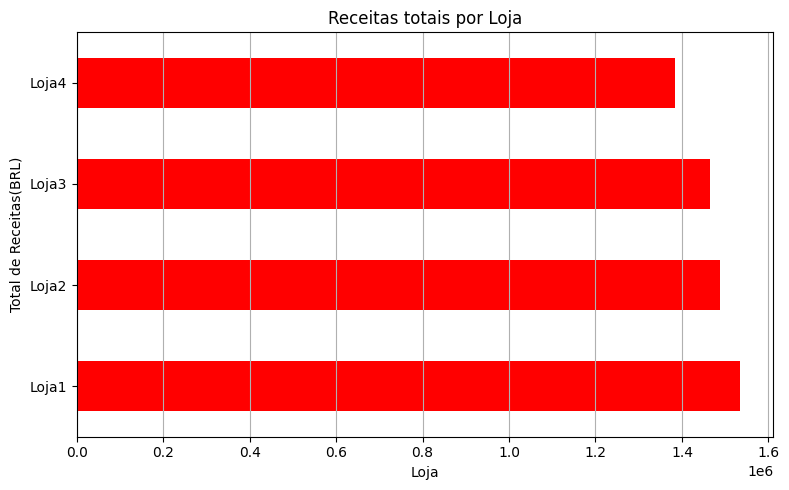

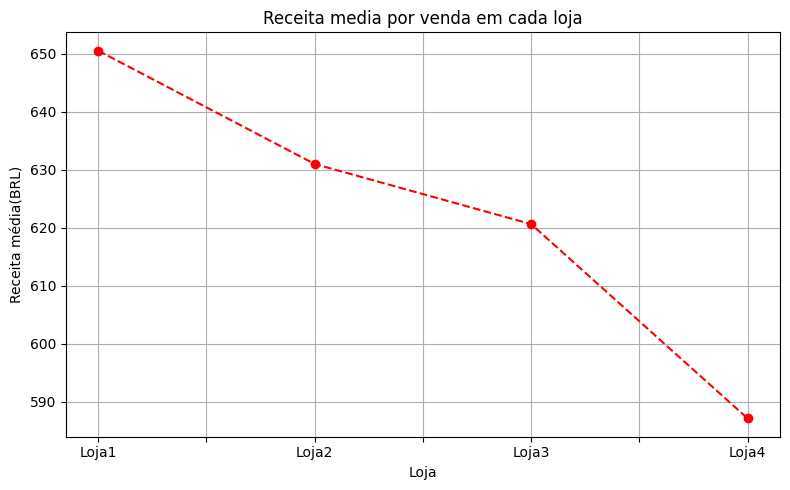

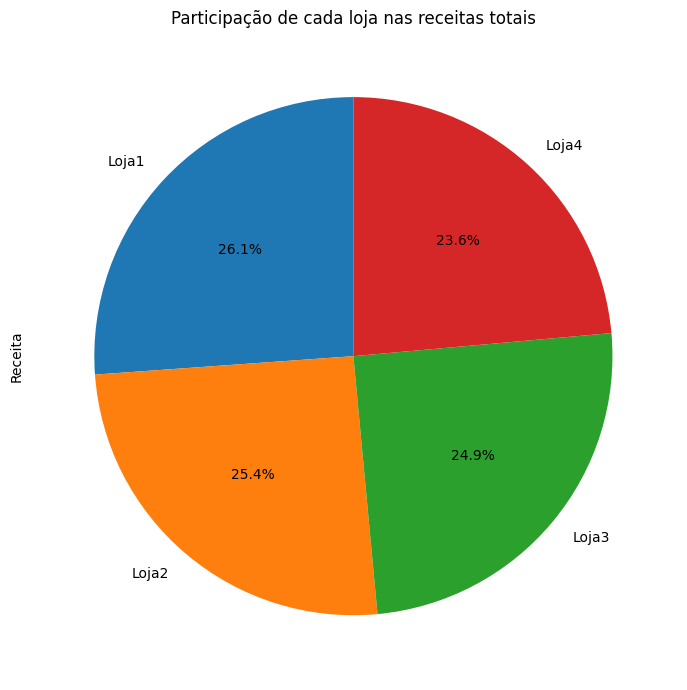

In [7]:
import matplotlib.pyplot as plt

df_total = pd.concat(
    [pd.read_csv(url).assign(Loja=f'Loja{i+1}')for i, url in enumerate(urls)],
    ignore_index=True
)

#Garantir formato correto
df_total['Preço'] = df_total['Preço'].astype(float)
df_total['Avaliação da compra'] = df_total['Avaliação da compra'].astype(float)

#Calcular avaliação média por loja
avaliacao_media = df_total.groupby('Local da compra')['Avaliação da compra'].mean()

#Ordenar os dados por valor
avaliacao_media = avaliacao_media.sort_values(ascending = False)

#A receita de cada venda é simplesmente o preço
df_total['Receita'] = df_total['Preço']

#Agrupar dados
receitas_totais = df_total.groupby('Loja')['Receita'].sum()
receita_media = df_total.groupby('Loja')['Receita'].mean()
distribuicao_receitas = receitas_totais

#Gerar 3 gráficos diferentes

#1. Barra vertical: Total de receitas
plt.figure(figsize = (8,5))
receitas_totais.plot(kind = 'barh', color = 'red')
plt.title('Receitas totais por Loja')
plt.ylabel('Total de Receitas(BRL)')
plt.xlabel('Loja')
plt.grid(axis = 'x')
plt.tight_layout()
plt.show()

#2. Linha: Receita média por venda
plt.figure(figsize=(8,5))
receita_media.plot(kind='line', marker='o', linestyle='--', color='red')
plt.title('Receita media por venda em cada loja')
plt.ylabel('Receita média(BRL)')
plt.xlabel('Loja')
plt.grid(True)
plt.tight_layout()
plt.show()

#3. Pizza: Distribuição do total
plt.figure(figsize=(7,7))
distribuicao_receitas.plot(kind = 'pie', autopct = '%1.1f%%', startangle = 90)
plt.title('Participação de cada loja nas receitas totais')
plt.ylabel=('')
plt.tight_layout()
plt.show()

#Consederações finais

#Relatório

Relatório de Análise de Desempenho das Lojas

Neste relatório, analiso o desempenho das quatro lojas do senhor João. Ao final, conforme solicitado, apresento uma sugestão sobre qual loja deve ser vendida, com base nos dados fornecidos.

Foram realizadas análises aprofundadas dos seguintes indicadores:

1.Receita total de cada loja – apresentada no primeiro gráfico;

2.Receita média por venda em cada loja – exibida no segundo gráfico;

3.Participação de cada loja no total de receitas – demonstrada no terceiro gráfico.

Com base nessa análise detalhada, recomendo ao senhor João a venda da Loja 4. Conforme evidenciado nos gráficos, essa loja apresenta desempenho inferior em todos os aspectos avaliados, tornando-se a opção menos vantajosa para manter na rede atual.